# DDPM vs DDIM 对比分析

本notebook实现了DDPM(Denoising Diffusion Probabilistic Models)和DDIM(Denoising Diffusion Implicit Models)两种扩散模型, 并分析它们的主要区别。

## 核心概念
- **DDPM**: 随机采样过程, 每步都添加随机噪声
- **DDIM**: 确定性采样过程, 可以选择步数进行快速采样

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm  # 使用标准tqdm而不是notebook版本

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']  # 黑体
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

# 设置随机种子以确保结果可重现
torch.manual_seed(42)
np.random.seed(42)

## 1. 定义噪声调度器

实现线性余弦噪声调度, 这是扩散模型的标准做法。

In [ ]:
class NoiseScheduler:
    def __init__(self, num_timesteps=1000, beta_start=0.0001, beta_end=0.02, scheduler_type='linear', device='cpu'):
        self.num_timesteps = num_timesteps
        self.scheduler_type = scheduler_type
        self.device = device
        
        if scheduler_type == 'linear':
            # 线性调度
            self.betas = torch.linspace(beta_start, beta_end, num_timesteps, device=device)
        elif scheduler_type == 'cosine':
            # 余弦调度
            steps = num_timesteps + 1
            x = torch.linspace(0, num_timesteps, steps, device=device) / num_timesteps
            alphas_cumprod = torch.cos((x + 0.008) / 1.008 * torch.pi / 2) ** 2
            alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
            betas = 1 - alphas_cumprod[1:] / alphas_cumprod[:-1]
            self.betas = torch.clamp(betas, 0, 0.999)
        
        # 计算alpha和alpha_bar
        self.alphas = 1.0 - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)  # 使用dim=0而不是axis=0
        self.alphas_cumprod_prev = F.pad(self.alphas_cumprod[:-1], (1, 0), value=1.0)
        
        # 预计算常用值
        self.sqrt_alphas_cumprod = torch.sqrt(self.alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - self.alphas_cumprod)
        self.sqrt_recip_alphas = torch.sqrt(1.0 / self.alphas)
        
        # 后验方差
        self.posterior_variance = (
            self.betas * (1.0 - self.alphas_cumprod_prev) / (1.0 - self.alphas_cumprod)
        )
    
    def add_noise(self, original, noise, timestep):
        """向原始数据添加噪声"""
        # 确保时间步张量在正确的设备上
        if hasattr(timestep, 'device') and timestep.device != self.device:
            timestep = timestep.to(self.device)
        
        sqrt_alpha_prod = self.sqrt_alphas_cumprod[timestep]
        sqrt_one_minus_alpha_prod = self.sqrt_one_minus_alphas_cumprod[timestep]
        
        # 重塑以匹配输入维度
        while len(sqrt_alpha_prod.shape) < len(original.shape):
            sqrt_alpha_prod = sqrt_alpha_prod.unsqueeze(-1)
            sqrt_one_minus_alpha_prod = sqrt_one_minus_alpha_prod.unsqueeze(-1)
            
        return sqrt_alpha_prod * original + sqrt_one_minus_alpha_prod * noise
    
    def get_ddpm_params(self, timestep):
        """获取DDPM采样所需的参数"""
        # 确保时间步在正确的设备上
        if hasattr(timestep, 'device') and timestep.device != self.device:
            timestep = timestep.to(self.device)
            
        beta = self.betas[timestep]
        sqrt_one_minus_alpha_prod = self.sqrt_one_minus_alphas_cumprod[timestep]
        sqrt_recip_alpha = self.sqrt_recip_alphas[timestep]
        posterior_variance = self.posterior_variance[timestep]
        
        return beta, sqrt_one_minus_alpha_prod, sqrt_recip_alpha, posterior_variance
    
    def get_ddim_params(self, timestep, prev_timestep, eta=0.0):
        """获取DDIM采样所需的参数"""
        # 确保时间步在正确的设备上
        if hasattr(timestep, 'device') and timestep.device != self.device:
            timestep = timestep.to(self.device)
        if hasattr(prev_timestep, 'device') and prev_timestep.device != self.device:
            prev_timestep = prev_timestep.to(self.device)
            
        alpha_cumprod_t = self.alphas_cumprod[timestep]
        if prev_timestep >= 0:
            alpha_cumprod_prev = self.alphas_cumprod[prev_timestep]
        else:
            alpha_cumprod_prev = torch.tensor(1.0, device=self.device)
        
        beta = self.betas[timestep]
        sqrt_alpha_t = torch.sqrt(alpha_cumprod_t)
        sqrt_alpha_prev_t = torch.sqrt(alpha_cumprod_prev)
        sqrt_one_minus_alpha_t = torch.sqrt(1 - alpha_cumprod_t)
        sqrt_one_minus_alpha_prev_t = torch.sqrt(1 - alpha_cumprod_prev)
        
        return alpha_cumprod_t, alpha_cumprod_prev, sqrt_alpha_t, sqrt_alpha_prev_t, sqrt_one_minus_alpha_t, sqrt_one_minus_alpha_prev_t

## 2. 简单的UNet模型

实现一个简化的UNet用于噪声预测。

In [3]:
class SimpleUNet(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=64):
        super().__init__()
        
        # 时间嵌入
        self.time_embedding = nn.Sequential(
            nn.Linear(128, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )
        
        # 编码器
        self.encoder = nn.Sequential(
            nn.Conv1d(input_dim + hidden_dim, hidden_dim, 3, padding=1),
            nn.SiLU(),
            nn.Conv1d(hidden_dim, hidden_dim * 2, 3, padding=1),
            nn.SiLU(),
            nn.Conv1d(hidden_dim * 2, hidden_dim * 2, 3, padding=1),
            nn.SiLU(),
        )
        
        # 解码器
        self.decoder = nn.Sequential(
            nn.Conv1d(hidden_dim * 2, hidden_dim * 2, 3, padding=1),
            nn.SiLU(),
            nn.Conv1d(hidden_dim * 2, hidden_dim, 3, padding=1),
            nn.SiLU(),
            nn.Conv1d(hidden_dim, input_dim, 3, padding=1)
        )
        
    def timestep_embedding(self, timesteps):
        """创建时间步嵌入"""
        half_dim = 64
        device = timesteps.device  # 获取输入张量的设备
        
        # 确保所有张量都在正确的设备上
        embeddings = torch.log(torch.tensor(10000.0, device=device)) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = timesteps[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=1)
        return embeddings
    
    def forward(self, x, t):
        # 时间嵌入
        t_emb = self.timestep_embedding(t)
        t_emb = self.time_embedding(t_emb)
        
        # 扩展时间嵌入以匹配空间维度
        while len(t_emb.shape) < len(x.shape):
            t_emb = t_emb.unsqueeze(-1)
        
        # 拼接输入和时间嵌入
        x_with_time = torch.cat([x, t_emb.expand(-1, -1, x.shape[-1])], dim=1)
        
        # 编码-解码
        encoded = self.encoder(x_with_time)
        decoded = self.decoder(encoded)
        
        return decoded

## 3. DDPM采样器

实现标准的DDPM采样过程, 这是一个随机过程。

In [4]:
class DDPMSampler:
    def __init__(self, model, scheduler):
        self.model = model
        self.scheduler = scheduler
    
    @torch.no_grad()
    def sample(self, shape, num_inference_steps=None, device='cpu'):
        if num_inference_steps is None:
            num_inference_steps = self.scheduler.num_timesteps
        
        # 从纯噪声开始
        x = torch.randn(shape, device=device)
        
        # 逆时间步采样
        timesteps = torch.linspace(
            self.scheduler.num_timesteps - 1, 0, num_inference_steps, dtype=torch.long, device=device
        )
        
        for t in tqdm(timesteps, desc="DDPM采样", leave=False):
            # 预测噪声
            t_batch = t.clone().detach().expand(shape[0]).to(device)
            predicted_noise = self.model(x, t_batch)
            
            # DDPM更新公式
            beta, sqrt_one_minus_alpha_prod, sqrt_recip_alpha, posterior_variance = self.scheduler.get_ddpm_params(t)
            
            # 预测的均值
            pred_mean = sqrt_recip_alpha * (x - beta / sqrt_one_minus_alpha_prod * predicted_noise)
            
            if t > 0:
                # 添加随机噪声
                noise = torch.randn_like(x)
                x = pred_mean + torch.sqrt(posterior_variance) * noise
            else:
                # 最后一步不需要添加噪声
                x = pred_mean
        
        return x

## 4. DDIM采样器

实现DDIM采样过程, 这是一个确定性过程, 可以进行快速采样。

In [5]:
class DDIMSampler:
    def __init__(self, model, scheduler):
        self.model = model
        self.scheduler = scheduler
    
    @torch.no_grad()
    def sample(self, shape, num_inference_steps=50, eta=0.0, device='cpu'):
        """
        DDIM采样
        eta: 控制随机性的参数 (0=完全确定性, 1=与DDPM相同)
        """
        # 生成子序列的时间步
        step_ratio = self.scheduler.num_timesteps // num_inference_steps
        timesteps = torch.arange(
            self.scheduler.num_timesteps - 1, -1, -step_ratio, dtype=torch.long, device=device
        )[:num_inference_steps]
        
        # 从纯噪声开始
        x = torch.randn(shape, device=device)
        
        for i, t in enumerate(tqdm(timesteps, desc="DDIM采样", leave=False)):
            # 预测噪声
            t_batch = t.clone().detach().expand(shape[0]).to(device)
            predicted_noise = self.model(x, t_batch)
            
            # 获取前一个时间步
            prev_t = timesteps[i + 1] if i < len(timesteps) - 1 else -1
            
            # DDIM参数
            alpha_cumprod_t, alpha_cumprod_prev, sqrt_alpha_t, sqrt_alpha_prev_t, sqrt_one_minus_alpha_t, sqrt_one_minus_alpha_prev_t = self.scheduler.get_ddim_params(t, prev_t)
            
            # 预测的原始数据
            pred_original_sample = sqrt_alpha_prev_t * (x - sqrt_one_minus_alpha_t * predicted_noise) / sqrt_alpha_t
            
            # 方差项
            if eta > 0:
                variance = eta * torch.sqrt((1 - alpha_cumprod_prev) / (1 - alpha_cumprod_t)) * (1 - alpha_cumprod_t / alpha_cumprod_prev)
            else:
                variance = 0
            
            # 前向过程的均值方向
            prev_sample_direction = torch.sqrt(1 - alpha_cumprod_prev - variance**2) * predicted_noise
            
            # 更新x
            if eta > 0:
                noise = torch.randn_like(x)
                x = pred_original_sample + prev_sample_direction + variance * noise
            else:
                x = pred_original_sample + prev_sample_direction
        
        return x

## 5. 训练函数

实现扩散模型的训练过程。

In [6]:
def train_diffusion_model(model, scheduler, dataloader, num_epochs=100, lr=1e-4, device='cpu'):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    losses = []
    
    model.train()
    for epoch in tqdm(range(num_epochs), desc="训练"):
        epoch_losses = []
        
        for batch in dataloader:
            batch = batch[0].to(device)  # 获取数据并移到设备
            
            # 随机选择时间步
            timesteps = torch.randint(0, scheduler.num_timesteps, (batch.shape[0],), device=device)
            
            # 生成噪声
            noise = torch.randn_like(batch)
            
            # 添加噪声到数据
            noisy_data = scheduler.add_noise(batch, noise, timesteps)
            
            # 预测噪声
            predicted_noise = model(noisy_data, timesteps)
            
            # 计算损失
            loss = F.mse_loss(predicted_noise, noise)
            
            # 反向传播
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            epoch_losses.append(loss.item())
        
        avg_loss = np.mean(epoch_losses)
        losses.append(avg_loss)
        
        if epoch % 10 == 0:
            tqdm.write(f"Epoch {epoch}, Loss: {avg_loss:.6f}")
    
    return losses

## 6. 生成示例数据

创建一些简单的一维数据用于演示。

训练数据形状: torch.Size([500, 1, 64])


C:\Users\xlong\AppData\Local\Temp\ipykernel_56756\3220093550.py:19: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:257.)
  return torch.tensor(data, dtype=torch.float32).unsqueeze(1)  # 添加channel维度


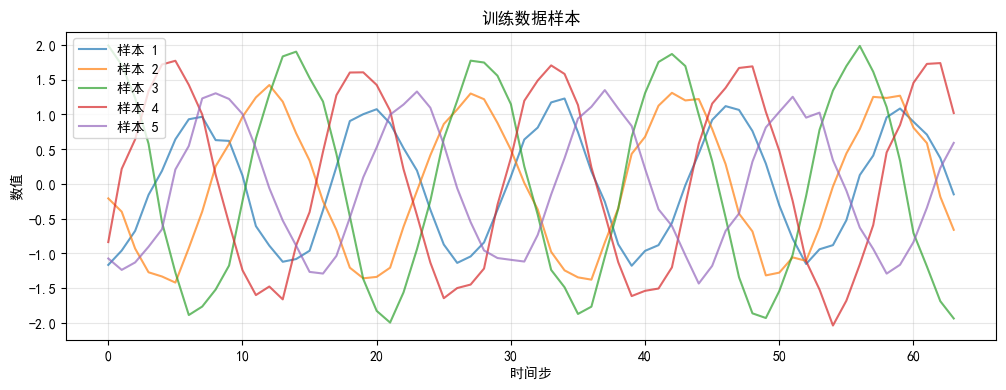

In [7]:
def generate_sample_data(n_samples=1000, seq_length=64):
    """生成示例数据：正弦波 + 随机相位"""
    data = []
    for i in range(n_samples):
        # 随机生成正弦波的参数
        amplitude = np.random.uniform(0.5, 2.0)
        frequency = np.random.uniform(1, 5)
        phase = np.random.uniform(0, 2 * np.pi)
        
        # 生成时间序列
        t = np.linspace(0, 1, seq_length)
        signal = amplitude * np.sin(2 * np.pi * frequency * t + phase)
        
        # 添加少量噪声
        signal += np.random.normal(0, 0.1, seq_length)
        
        data.append(signal)
    
    return torch.tensor(data, dtype=torch.float32).unsqueeze(1)  # 添加channel维度

# 生成数据
train_data = generate_sample_data(n_samples=500, seq_length=64)
print(f"训练数据形状: {train_data.shape}")

# 可视化一些样本
plt.figure(figsize=(12, 4))
for i in range(5):
    plt.plot(train_data[i, 0].numpy(), alpha=0.7, label=f'样本 {i+1}')
plt.title('训练数据样本')
plt.xlabel('时间步')
plt.ylabel('数值')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 7. 训练模型

训练扩散模型并监控损失。

使用设备: cuda
开始训练扩散模型...


训练:   8%|▊         | 4/50 [00:00<00:04, 11.34it/s]

Epoch 0, Loss: 1.022284


训练:  32%|███▏      | 16/50 [00:00<00:01, 21.37it/s]  

Epoch 10, Loss: 0.256788


...

训练:  68%|██████▊   | 34/50 [00:01<00:00, 25.67it/s]  

Epoch 30, Loss: 0.230817


训练:  86%|████████▌ | 43/50 [00:01<00:00, 24.88it/s]  

Epoch 40, Loss: 0.251901


训练: 100%|██████████| 50/50 [00:02<00:00, 22.23it/s]


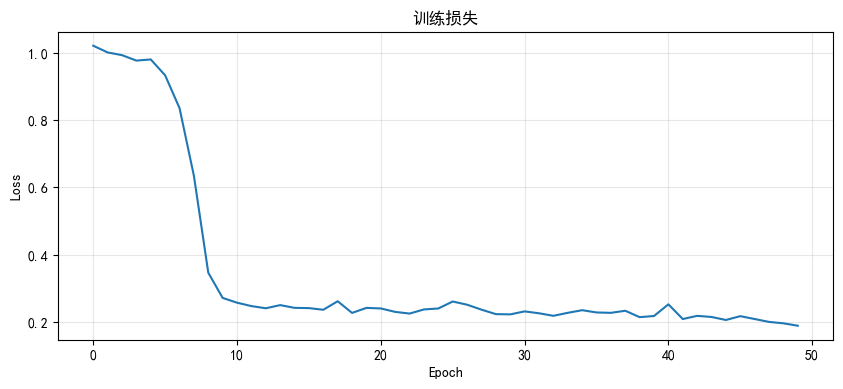

In [8]:
# 设置参数
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"使用设备: {device}")

# 创建调度器和模型, 指定设备
scheduler = NoiseScheduler(num_timesteps=1000, scheduler_type='linear', device=device)
model = SimpleUNet(input_dim=1, hidden_dim=32).to(device)

# 创建数据加载器
batch_size = 32
from torch.utils.data import DataLoader, TensorDataset
dataset = TensorDataset(train_data)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# 训练模型
print("开始训练扩散模型...")
losses = train_diffusion_model(model, scheduler, dataloader, num_epochs=50, lr=1e-4, device=device)

# 绘制损失曲线
plt.figure(figsize=(10, 4))
plt.plot(losses)
plt.title('训练损失')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.show()

## 8. DDPM vs DDIM 采样对比

比较两种采样方法的结果和速度。

In [9]:
import time

# 创建采样器
ddpm_sampler = DDPMSampler(model, scheduler)
ddim_sampler = DDIMSampler(model, scheduler)

# 生成样本
num_samples = 4
seq_length = 64
sample_shape = (num_samples, 1, seq_length)

# DDPM采样
print("DDPM采样 (1000步)...")
start_time = time.time()
ddpm_samples = ddpm_sampler.sample(sample_shape, num_inference_steps=1000, device=device)
ddpm_time = time.time() - start_time
print(f"DDPM采样时间: {ddpm_time:.2f}秒")

# DDIM采样 (50步)
print("\nDDIM采样 (50步)...")
start_time = time.time()
ddim_samples = ddim_sampler.sample(sample_shape, num_inference_steps=50, eta=0.0, device=device)
ddim_time = time.time() - start_time
print(f"DDIM采样时间: {ddim_time:.2f}秒")

# DDIM采样 (100步)
print("\nDDIM采样 (100步)...")
start_time = time.time()
ddim_samples_100 = ddim_sampler.sample(sample_shape, num_inference_steps=100, eta=0.0, device=device)
ddim_time_100 = time.time() - start_time
print(f"DDIM采样时间: {ddim_time_100:.2f}秒")

print(f"\n速度提升: DDIM(50步) vs DDPM: {ddpm_time/ddim_time:.1f}x")
print(f"速度提升: DDIM(100步) vs DDPM: {ddpm_time/ddim_time_100:.1f}x")

DDPM采样 (1000步)...


DDPM采样时间: 1.01秒

DDIM采样 (50步)...


DDIM采样时间: 0.05秒

DDIM采样 (100步)...


DDIM采样时间: 0.10秒

速度提升: DDIM(50步) vs DDPM: 19.7x
速度提升: DDIM(100步) vs DDPM: 9.9x


## 9. 可视化对比结果

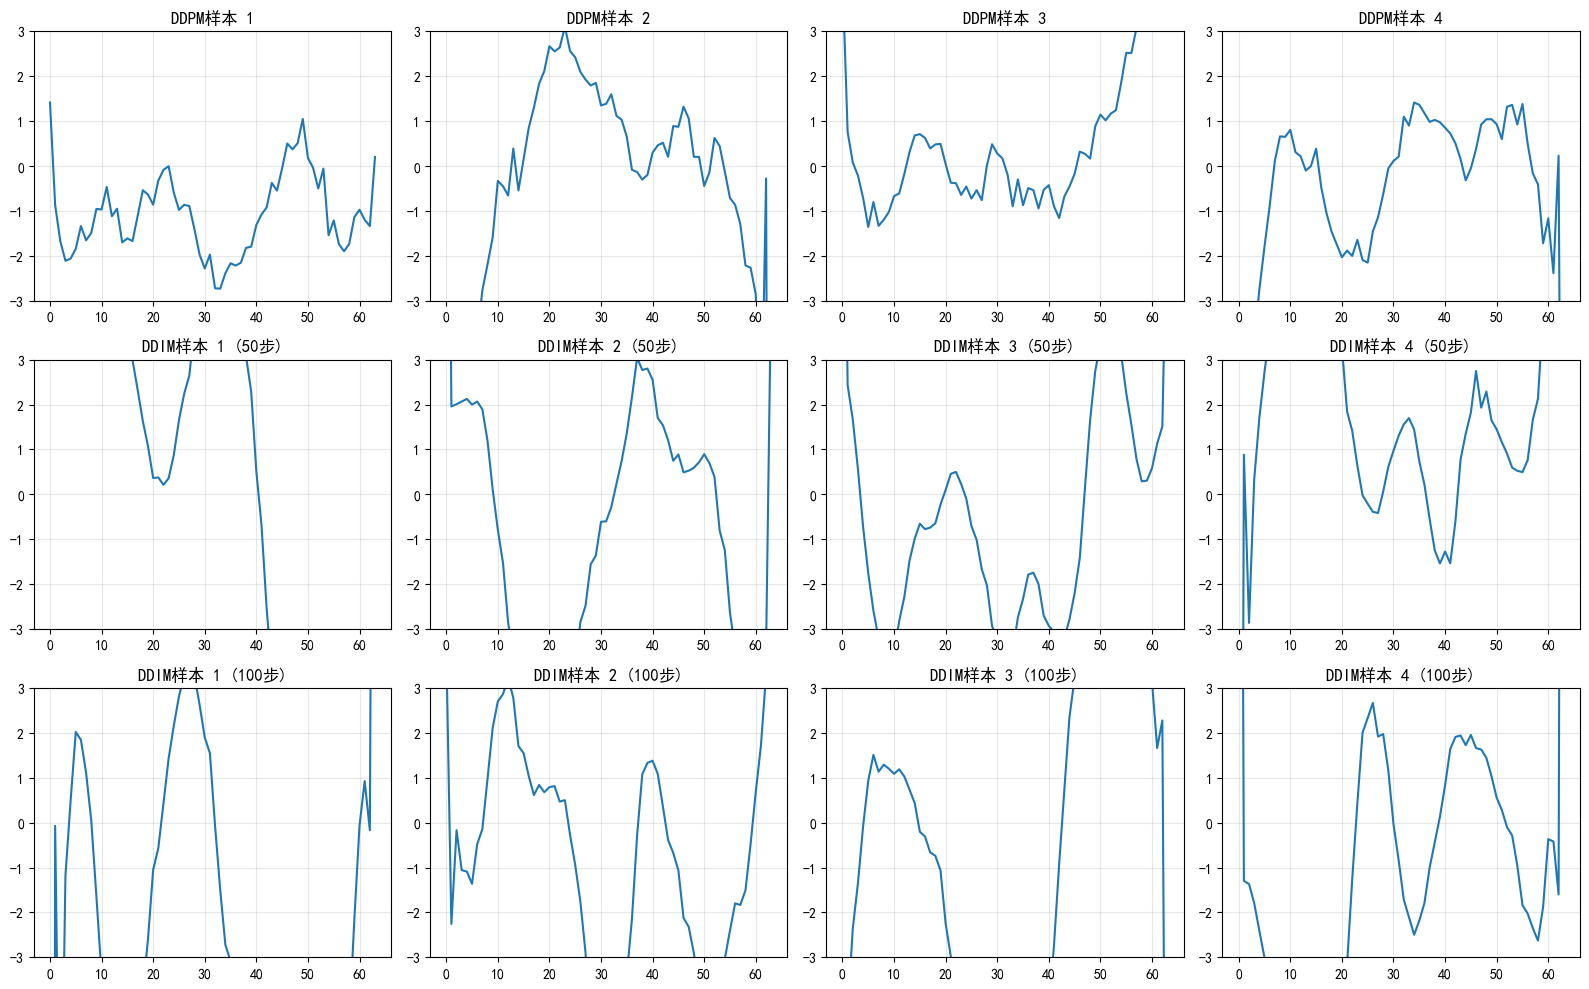

In [10]:
# 将样本移到CPU用于可视化
ddpm_samples = ddpm_samples.cpu()
ddim_samples = ddim_samples.cpu()
ddim_samples_100 = ddim_samples_100.cpu()

# 可视化结果
fig, axes = plt.subplots(3, num_samples, figsize=(16, 10))

for i in range(num_samples):
    # DDPM结果
    axes[0, i].plot(ddpm_samples[i, 0].numpy())
    axes[0, i].set_title(f'DDPM样本 {i+1}')
    axes[0, i].set_ylim([-3, 3])
    axes[0, i].grid(True, alpha=0.3)
    
    # DDIM结果 (50步)
    axes[1, i].plot(ddim_samples[i, 0].numpy())
    axes[1, i].set_title(f'DDIM样本 {i+1} (50步)')
    axes[1, i].set_ylim([-3, 3])
    axes[1, i].grid(True, alpha=0.3)
    
    # DDIM结果 (100步)
    axes[2, i].plot(ddim_samples_100[i, 0].numpy())
    axes[2, i].set_title(f'DDIM样本 {i+1} (100步)')
    axes[2, i].set_ylim([-3, 3])
    axes[2, i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 10. DDIM的eta参数分析

DDIM中的eta参数控制随机性：
- eta = 0: 完全确定性, 最快的采样
- eta = 1: 与DDPM相同的随机性

DDIM采样 (eta=0.0)...


DDIM采样 (eta=0.3)...


DDIM采样 (eta=0.6)...


DDIM采样 (eta=1.0)...


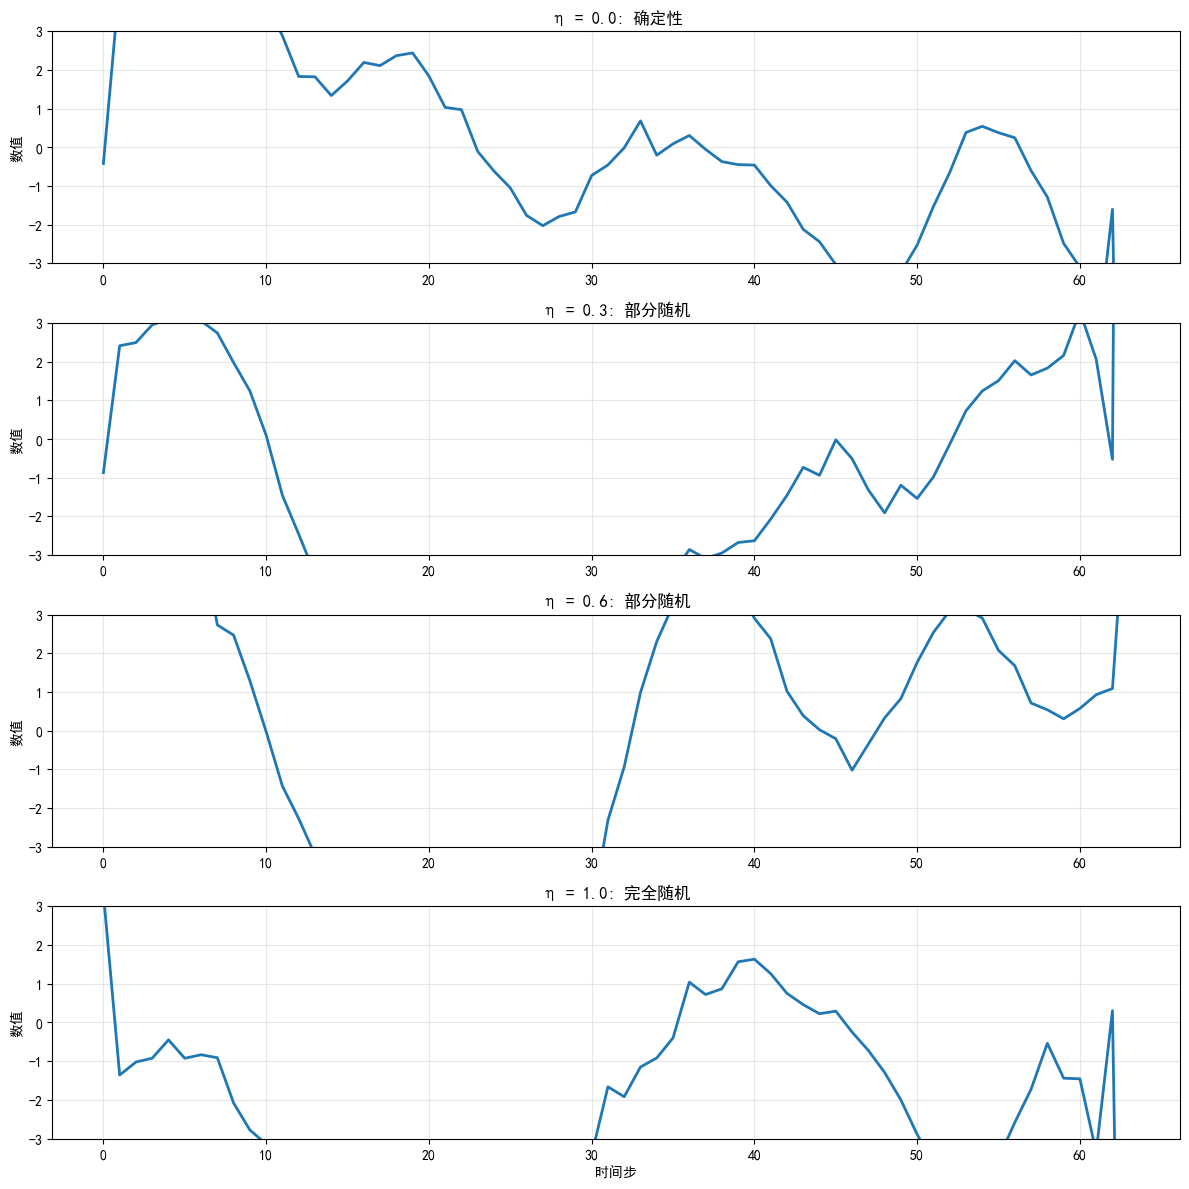

In [11]:
# 测试不同的eta值
eta_values = [0.0, 0.3, 0.6, 1.0]
eta_samples = {}

for eta in eta_values:
    print(f"DDIM采样 (eta={eta})...")
    samples = ddim_sampler.sample(sample_shape, num_inference_steps=50, eta=eta, device=device)
    eta_samples[eta] = samples.cpu()  # 移到CPU

# 可视化不同eta值的对比
fig, axes = plt.subplots(len(eta_values), 1, figsize=(12, 3*len(eta_values)))

for idx, eta in enumerate(eta_values):
    # 绘制每个eta值下的第一个样本
    axes[idx].plot(eta_samples[eta][0, 0].numpy(), linewidth=2)
    axes[idx].set_title(f'η = {eta}: {"确定性" if eta == 0 else "部分随机" if eta < 1 else "完全随机"}')
    axes[idx].set_ylim([-3, 3])
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_ylabel('数值')

axes[-1].set_xlabel('时间步')
plt.tight_layout()
plt.show()

## 11. 质量对比分析

比较不同采样方法生成的样本与真实数据的分布差异。

生成大量样本进行统计比较...



统计指标对比 (与真实数据的差异):
           DDPM (1000步)  DDIM (50步)  DDIM (100步)
mean_diff      0.326100    0.586900     0.471600
std_diff       3.255800    8.555700     7.648800
min_diff      82.337997  174.377808   152.051804
max_diff      75.450104  112.247498   131.265793


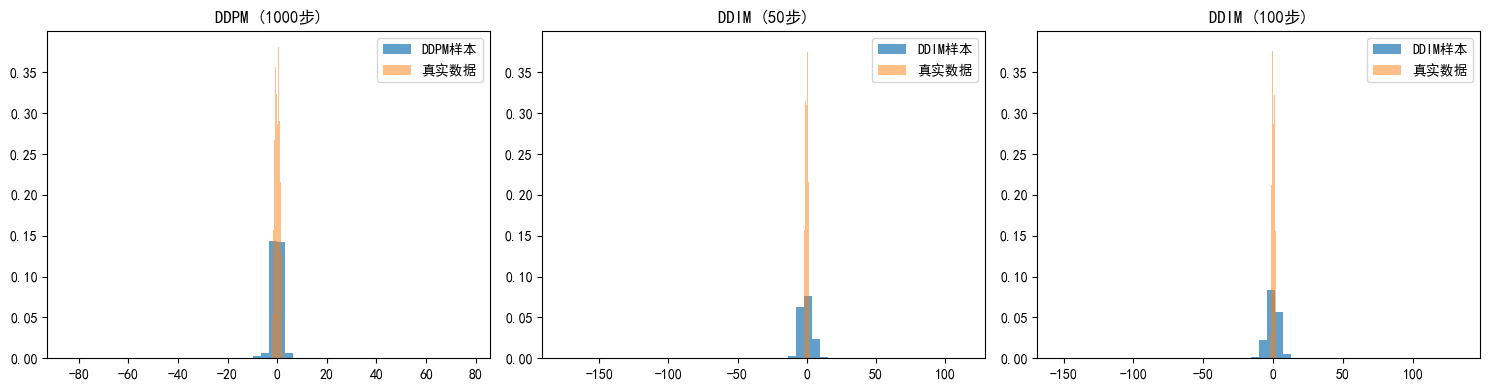

In [12]:
# 计算统计指标进行比较
def compute_statistics(samples, real_data):
    """计算样本的统计指标"""
    # 确保张量在CPU上, 然后转换为numpy
    if hasattr(samples, 'cpu'):
        samples_flat = samples.cpu().flatten().numpy()
    else:
        samples_flat = samples.flatten()
    
    if hasattr(real_data, 'cpu'):
        real_flat = real_data.cpu().flatten().numpy()
    else:
        real_flat = real_data.flatten()
    
    stats = {
        'mean_diff': abs(np.mean(samples_flat) - np.mean(real_flat)),
        'std_diff': abs(np.std(samples_flat) - np.std(real_flat)),
        'min_diff': abs(np.min(samples_flat) - np.min(real_flat)),
        'max_diff': abs(np.max(samples_flat) - np.max(real_flat))
    }
    
    return stats

# 生成更多样本用于统计
large_sample_shape = (100, 1, seq_length)

print("生成大量样本进行统计比较...")
ddpm_large = ddpm_sampler.sample(large_sample_shape, num_inference_steps=1000, device=device)
ddim_50_large = ddim_sampler.sample(large_sample_shape, num_inference_steps=50, eta=0.0, device=device)
ddim_100_large = ddim_sampler.sample(large_sample_shape, num_inference_steps=100, eta=0.0, device=device)

# 计算统计指标
ddpm_stats = compute_statistics(ddpm_large, train_data)
ddim_50_stats = compute_statistics(ddim_50_large, train_data)
ddim_100_stats = compute_statistics(ddim_100_large, train_data)

# 创建比较表格
import pandas as pd
df = pd.DataFrame({
    'DDPM (1000步)': ddpm_stats,
    'DDIM (50步)': ddim_50_stats,
    'DDIM (100步)': ddim_100_stats
})

print("\n统计指标对比 (与真实数据的差异):")
print(df.round(4))

# 可视化分布对比
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 确保数据在CPU上用于绘图
ddpm_large_cpu = ddpm_large.cpu().flatten().numpy()
ddim_50_large_cpu = ddim_50_large.cpu().flatten().numpy()
ddim_100_large_cpu = ddim_100_large.cpu().flatten().numpy()
train_data_cpu = train_data.flatten().numpy()

# DDPM
axes[0].hist(ddpm_large_cpu, bins=50, alpha=0.7, density=True, label='DDPM样本')
axes[0].hist(train_data_cpu, bins=50, alpha=0.5, density=True, label='真实数据')
axes[0].set_title('DDPM (1000步)')
axes[0].legend()

# DDIM 50步
axes[1].hist(ddim_50_large_cpu, bins=50, alpha=0.7, density=True, label='DDIM样本')
axes[1].hist(train_data_cpu, bins=50, alpha=0.5, density=True, label='真实数据')
axes[1].set_title('DDIM (50步)')
axes[1].legend()

# DDIM 100步
axes[2].hist(ddim_100_large_cpu, bins=50, alpha=0.7, density=True, label='DDIM样本')
axes[2].hist(train_data_cpu, bins=50, alpha=0.5, density=True, label='真实数据')
axes[2].set_title('DDIM (100步)')
axes[2].legend()

plt.tight_layout()
plt.show()

## 12. 总结与结论

### DDPM vs DDIM 主要区别：

1. **采样过程**:
   - DDPM: 随机采样, 每步都添加随机噪声
   - DDIM: 确定性采样(当η=0时), 不添加随机噪声

2. **采样速度**:
   - DDPM: 需要完整的1000步采样过程
   - DDIM: 可以选择更少的步数(如20-50步), 显著提高速度

3. **随机性控制**:
   - DDPM: 固定的随机性
   - DDIM: 通过η参数可以调节随机性程度

4. **样本质量**:
   - DDPM: 通常质量最高, 但速度慢
   - DDIM: 在较少步数下仍能保持较好质量

### 使用建议：
- **需要最高质量**: 使用DDPM (1000步)
- **需要快速推理**: 使用DDIM (20-50步, η=0)
- **需要多样性**: 使用DDIM (η=0.5-1.0)

### 技术要点：
- DDIM通过重新参数化实现了非马尔可夫的采样过程
- DDIM在η=0时可以实现确定性采样, 这对于图像编辑和插值很有用
- DDIM保持了与DDPM相同的边际分布, 确保了理论正确性